In [6]:
# DBSCAN con Mall_Customers.csv (ejemplo completo)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 1) Cargar dataset
df = pd.read_csv("Mall_Customers.csv")

# 2) Usamos las 2 variables clásicas para graficar clustering
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].to_numpy()

# 3) Escalar (muy recomendado para DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) k-distance plot para orientar eps (k = min_samples)
# NearestNeighbors se usa para encontrar una distancia razonable (eps) para DBSCAN, en lugar de elegirla al azar.
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)

In [7]:
k_dist = np.sort(distances[:, -1])  # distancia al k-ésimo vecino

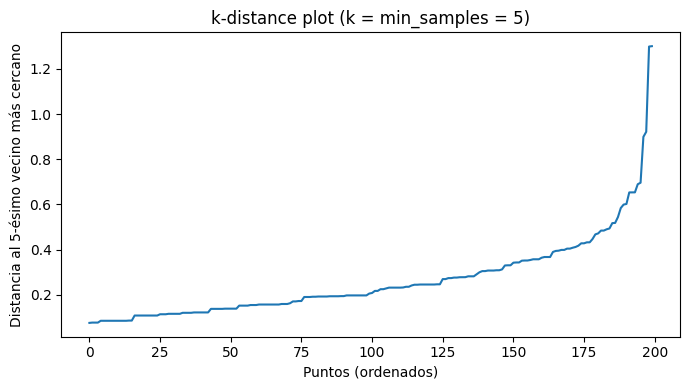

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(k_dist)
plt.title(f"k-distance plot (k = min_samples = {min_samples})")
plt.xlabel("Puntos (ordenados)")
plt.ylabel(f"Distancia al {min_samples}-ésimo vecino más cercano")
plt.tight_layout()
plt.show()

Este gráfico es el que se usa para elegir eps en DBSCAN

Primero recuerda qué representa cada eje:
* Eje X: puntos del dataset ordenados
* Eje Y: distancia al 5º vecino más cercano (porque min_samples = 5)

Cada punto del gráfico dice:
“Para este punto, ¿a qué distancia está su 5º vecino más cercano?”

Lo importante del gráfico:
Hay que buscar dónde la curva empieza a subir bruscamente.

En el gráfico ocurre aproximadamente aquí:
* hasta ≈ 0.4 la curva sube suave
* después de ≈ 0.5 – 0.6 empieza a crecer rápido
* luego se dispara cerca de 1.0

Ese cambio de pendiente se llama “elbow” o codo.

Entonces ¿qué eps elegir?

Una regla práctica es elegir un valor justo antes de la subida fuerte.

En tu gráfico sería razonable algo como: 0.45

In [9]:
# 5) Probar algunos eps (opcional, útil para elegir)
eps_candidates = [0.35, 0.40, 0.45, 0.50, 0.60]
for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_noise = int(np.sum(labels == -1))
    n_clusters = int(len(set(labels)) - (1 if -1 in labels else 0))
    print(f"eps={eps:.2f} -> clusters={n_clusters}, ruido={n_noise}")

eps=0.35 -> clusters=6, ruido=23
eps=0.40 -> clusters=4, ruido=15
eps=0.45 -> clusters=3, ruido=11
eps=0.50 -> clusters=2, ruido=8
eps=0.60 -> clusters=1, ruido=5



DBSCAN final: clusters=3, ruido=11
-1     11
 0    144
 1     11
 2     34
Name: count, dtype: int64


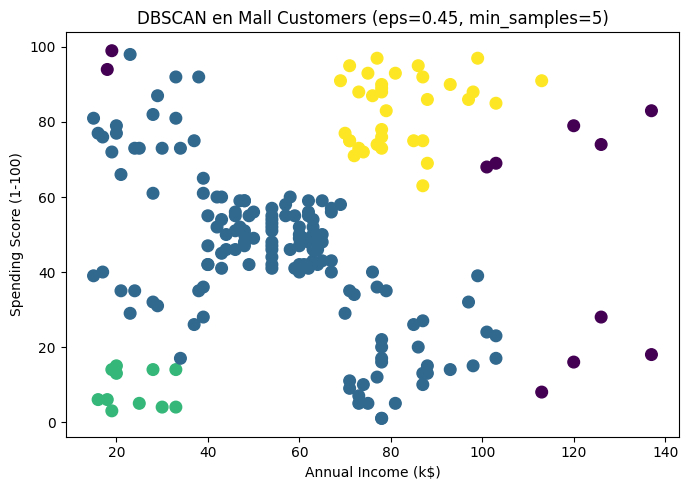

In [10]:
# 6) Entrenar DBSCAN con un eps elegido (ajusta según tu gráfico)
eps = 0.45
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled)

# 7) Resumen
n_noise = int(np.sum(labels == -1))
n_clusters = int(len(set(labels)) - (1 if -1 in labels else 0))
print(f"\nDBSCAN final: clusters={n_clusters}, ruido={n_noise}")
print(pd.Series(labels).value_counts().sort_index())

# 8) Gráfico (ruido = -1)
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=70)
plt.title(f"DBSCAN en Mall Customers (eps={eps}, min_samples={min_samples})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()